In [1]:
import os
import cv2
import logging
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.metrics as metrics
from sklearn.metrics import roc_curve, auc

2026-05-11 09:45:31.095988: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778492731.327855      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778492731.394921      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778492731.919813      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778492731.919868      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778492731.919871      23 computation_placer.cc:177] computation placer alr

In [2]:
# --- 1. GPU & ACCELERATION SETUP ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

Number of GPUs: 2


I0000 00:00:1778492759.619595      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778492759.625712      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# --- 2. DATA LOADING (MANUAL CSVs - FIXED SEPARATOR) ---
# We add sep=';' because your files use semicolons
# train_df = pd.read_csv('/kaggle/input/datasets/damonwangzc/after-data-clearning/Training - dataset 1 - No findings over 12 years uniq.csv', sep=';')
# valid_df = pd.read_csv('/kaggle/input/datasets/damonwangzc/after-data-clearning/Validation - dataset 1 - No findings over 12 years uniq.csv', sep=';')
# test_df = pd.read_csv('/kaggle/input/datasets/damonwangzc/after-data-clearning/Test - dataset 1 - No findings over 12 years uniq.csv', sep=';')

train_df = pd.read_csv('/kaggle/input/datasets/damonwangzc/after-data-clearning/Training - dataset 2 - All uniq patients first image 13-95 years.csv', sep=';')
valid_df = pd.read_csv('/kaggle/input/datasets/damonwangzc/after-data-clearning/Validation - dataset 2 - All uniq patients first image 13-95 years.csv', sep=';')
test_df = pd.read_csv('/kaggle/input/datasets/damonwangzc/after-data-clearning/Test - dataset 2 - All uniq patients first image 13-95 years.csv', sep=';')


# Check if it worked
print("Fixed Train Columns:", train_df.columns.tolist())

Fixed Train Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]']


In [4]:
# --- 3. PATH MAPPING (UPDATED) ---
csv_search = glob('/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv', recursive=True)
dataset_root = os.path.dirname(csv_search[0])

print("Mapping image paths...")
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join(dataset_root, '**', '*.png'), recursive=True)}

for name, df in [("Train", train_df), ("Val", valid_df), ("Test", test_df)]:
    # Map the path using the 'Image Index' column
    df['path'] = df['Image Index'].map(all_image_paths.get)
    
    # Map Gender (Male=0, Female=1)
    # Using the exact name 'Patient Gender' from your CSV
    df['Gender_Label'] = df['Patient Gender'].map({'M': 0, 'F': 1})
    
    # Drop rows where images were not found
    initial_len = len(df)
    df.dropna(subset=['path', 'Gender_Label'], inplace=True)
    
    print(f"{name} set: {len(df)} images ready (Found {len(df)} out of {initial_len})")

print(f"\nFinal Ready Counts -> Train: {len(train_df)}, Val: {len(valid_df)}, Test: {len(test_df)}")

Mapping image paths...
Train set: 20952 images ready (Found 20952 out of 20952)
Val set: 4490 images ready (Found 4490 out of 4490)
Test set: 4489 images ready (Found 4489 out of 4489)

Final Ready Counts -> Train: 20952, Val: 4490, Test: 4489


In [5]:
# --- 4. PREPROCESSING FUNCTION ---
def medical_preprocessing(img):
    img = img.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    if len(img.shape) == 2 or img.shape[2] == 1:
        img_clahe = clahe.apply(img if len(img.shape)==2 else img[:,:,0])
        img_final = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    else:
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        lab = cv2.merge((l2, a, b))
        img_final = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return img_final.astype(np.float32) / 255.0

In [6]:
# --- 5. DATA GENERATORS ---
IMG_SIZE = (320, 320)
BATCH_SIZE = 32 * strategy.num_replicas_in_sync 

train_datagen = ImageDataGenerator(preprocessing_function=medical_preprocessing, horizontal_flip=True, rotation_range=5)
test_datagen = ImageDataGenerator(preprocessing_function=medical_preprocessing)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='path', y_col='Gender_Label',
    class_mode='raw', target_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)

valid_gen = test_datagen.flow_from_dataframe(
    dataframe=valid_df, x_col='path', y_col='Gender_Label',
    class_mode='raw', target_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='path', y_col='Gender_Label',
    class_mode='raw', target_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

Found 20952 validated image filenames.
Found 4490 validated image filenames.
Found 4489 validated image filenames.


In [7]:
# --- 6. MODEL ARCHITECTURE ---
def build_gender_model():
    with strategy.scope():
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
        base_model.trainable = True
        for layer in base_model.layers[:-30]:
            layer.trainable = False

        x = GlobalAveragePooling2D()(base_model.output)
        x = Dropout(0.3)(x)
        predictions = Dense(1, activation='sigmoid', dtype='float32')(x)
        
        model = Model(inputs=base_model.input, outputs=predictions)
        model.compile(
            optimizer=Adam(learning_rate=1e-4),
            loss='binary_crossentropy',
            metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.AUC(name='auc')]
        )
    return model

model = build_gender_model()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# --- 7. TRAINING ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_gender_model.keras', monitor='val_auc', mode='max', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]

history = model.fit(
    train_gen,
    epochs=12,
    validation_data=valid_gen,
    steps_per_epoch=len(train_gen),
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12


I0000 00:00:1778492985.670460      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778492985.670478      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


328/328 ━━━━━━━━━━━━━━━━━━━━ 1216s 4s/step - accuracy: 0.7900 - auc: 0.8666 - loss: 0.4317 - val_accuracy: 0.9383 - val_auc: 0.9900 - val_loss: 0.1595 - learning_rate: 1.0000e-04
Epoch 2/12
328/328 ━━━━━━━━━━━━━━━━━━━━ 957s 3s/step - accuracy: 0.9485 - auc: 0.9886 - loss: 0.1424 - val_accuracy: 0.9604 - val_auc: 0.9943 - val_loss: 0.1085 - learning_rate: 1.0000e-04
Epoch 3/12
328/328 ━━━━━━━━━━━━━━━━━━━━ 966s 3s/step - accuracy: 0.9673 - auc: 0.9948 - loss: 0.0964 - val_accuracy: 0.9695 - val_auc: 0.9957 - val_loss: 0.0840 - learning_rate: 1.0000e-04
Epoch 4/12
328/328 ━━━━━━━━━━━━━━━━━━━━ 959s 3s/step - accuracy: 0.9696 - auc: 0.9956 - loss: 0.0849 - val_accuracy: 0.9588 - val_auc: 0.9950 - val_loss: 0.1086 - learning_rate: 1.0000e-04
Epoch 5/12
328/328 ━━━━━━━━━━━━━━━━━━━━ 949s 3s/step - accuracy: 0.9770 - auc: 0.9972 - loss: 0.0690 - val_accuracy: 0.9706 - val_auc: 0.9958 - val_loss: 0.0829 - learning_rate: 1.0000e-04
Epoch 6/12
328/328 ━━━━━━━━━━━━━━━━━━━━ 950s 3s/step - accuracy: 

71/71 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step


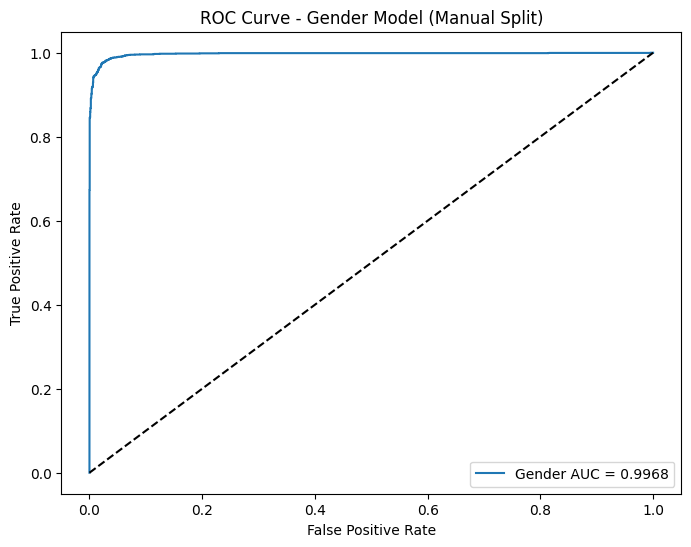

In [9]:
# --- 8. FINAL EVALUATION ---
test_gen.reset()
predictions = model.predict(test_gen, steps=len(test_gen))
fpr, tpr, _ = roc_curve(test_df['Gender_Label'], predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Gender AUC = {roc_auc:.4f}')
plt.plot([0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gender Model (Manual Split)')
plt.legend()
plt.show()